In [158]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import RidgeCV, ElasticNetCV, LassoCV
import re
#ini mek untuk biar nek error pendek
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data

In [159]:
try:
    train_df = pd.read_csv('datatrain.csv')
    test_df = pd.read_csv('datatest.csv')
    submission_dates = test_df['date']
    print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")
    print(train_df.info())
    display(train_df.head())
except FileNotFoundError:
    print("Make sure 'datatrain.csv' and 'datatest.csv' are in the same directory.")
    exit()

Train shape: (1606, 60), Test shape: (402, 59)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 60 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   obs_id                         1606 non-null   int64  
 1   date                           1606 non-null   object 
 2   daily_ktCO2                    1606 non-null   float64
 3   pm25                           1604 non-null   float64
 4   pm10                           1604 non-null   float64
 5   o3                             1604 non-null   float64
 6   no2                            1580 non-null   float64
 7   so2                            331 non-null    object 
 8   env_index                      1606 non-null   float64
 9   Car_7-9                        310 non-null    float64
 10  Van_7-9                        310 non-null    float64
 11  Bus_7-9                        310 non-null    float64
 12  M

,obs_id,date,daily_ktCO2,pm25,pm10,o3,no2,so2,env_index,Car_7-9,...,cloudcover,visibility,solarradiation,solarenergy,uvindex,moonphase,conditions,weekend,seasons,holiday
0,1,1/1/2020,42.471115,74.0,46.0,11.0,15.0,NaN,0.506768,NaN,...,47.4,9.9,113.1,9.9,5.0,0.19,Partially cloudy,False,NaN,Yes
1,2,1/2/2020,44.128139,93.0,52.0,12.0,18.0,NaN,0.673507,NaN,...,34.4,10.0,82.6,7.2,3.0,0.22,Partially cloudy,False,Cool,No
2,3,1/3/2020,44.960525,102.0,56.0,16.0,18.0,NaN,0.440693,NaN,...,35.5,9.8,88.8,7.8,3.0,0.25,Partially cloudy,False,Cool,No
3,4,1/4/2020,44.524260,121.0,61.0,15.0,17.0,NaN,0.109702,NaN,...,30.4,9.9,85.3,7.3,3.0,0.29,NaN,NaN,Cool,Yes
4,5,1/5/2020,44.428186,130.0,66.0,14.0,27.0,NaN,0.643137,NaN,...,31.6,9.7,88.7,7.5,3.0,0.32,Partially cloudy,NaN,Cool,Yes


We have data with originally 60 features and several columns with null values. We will clean this in subsequent steps.

# 2. Data Cleaning

In [160]:
# Saving train & test IDs and y train
train_ids = train_df['obs_id']
test_ids = test_df['obs_id']
train_y = train_df['daily_ktCO2']

print(f"Target stats - Mean: {train_y.mean():.3f}, Std: {train_y.std():.3f}")
print(f"Target range: [{train_y.min():.3f}, {train_y.max():.3f}]")

# Combine both train and test to be cleaned the same way
train_df = train_df.drop(columns=['daily_ktCO2', 'obs_id'])
test_df = test_df.drop(columns=['obs_id'])
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

Target stats - Mean: 47.919, Std: 5.588
Target range: [31.501, 64.051]


The test data's daily CO2 ranges from 31.501 to 64.051 with mean 47.919 and standard deviation 5.588

In [161]:
# convert date column to pandas datetime
combined_df['date'] = pd.to_datetime(combined_df['date'])

In [162]:
# the column so2 is still object type, we need to convert it to numeric
combined_df['so2'] = pd.to_numeric(combined_df['so2'], errors='coerce')
combined_df['so2'].unique()

array([nan,  2.,  1.,  3.,  4.,  7.,  6., 10., 13.,  5., 17., 15., 22.,
        8.,  9., 11., 20., 12., 14., 19., 16., 25., 26., 34., 21.])

In [ ]:
# Convert boolean-like columns to integer 0/1
bool_cols = ['rain', 'weekend', 'holiday']
for col in bool_cols:
    if col in combined_df.columns:
        map_dict = {'true': "yes", 'yes': "yes", 'false': "no", 'no': "no"}
        combined_df[col] = combined_df[col].astype(str).str.strip().str.lower().map(map_dict)

In [164]:
# Lower all string column
text_cols = combined_df.select_dtypes(include=['object']).columns
for col in text_cols:
    combined_df[col] = combined_df[col].map(lambda x: x.lower().strip() if pd.notnull(x) else x)

# check the inside
for col in text_cols:
    print(f"Unique values in '{col}': {combined_df[col].unique()}")
    print("-" * 40)

Unique values in 'conditions': ['partially cloudy' nan 'clear' 'rain, partially cloudy']
----------------------------------------
Unique values in 'seasons': [nan 'cool' 'hot' 'rainy']
----------------------------------------


All text values have been lower-cased.

In [165]:
train_df = combined_df.iloc[train_ids-1]
test_df = combined_df.iloc[test_ids-1]
train_df['daily_ktCO2'] = train_y

In [166]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1606 entries, 0 to 1605
Data columns (total 59 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   date                           1606 non-null   datetime64[ns]
 1   pm25                           1604 non-null   float64       
 2   pm10                           1604 non-null   float64       
 3   o3                             1604 non-null   float64       
 4   no2                            1580 non-null   float64       
 5   so2                            330 non-null    float64       
 6   env_index                      1606 non-null   float64       
 7   Car_7-9                        310 non-null    float64       
 8   Van_7-9                        310 non-null    float64       
 9   Bus_7-9                        310 non-null    float64       
 10  Minibus_7-9                    310 non-null    float64       
 11  Truck_7-9             

# 3. EDA

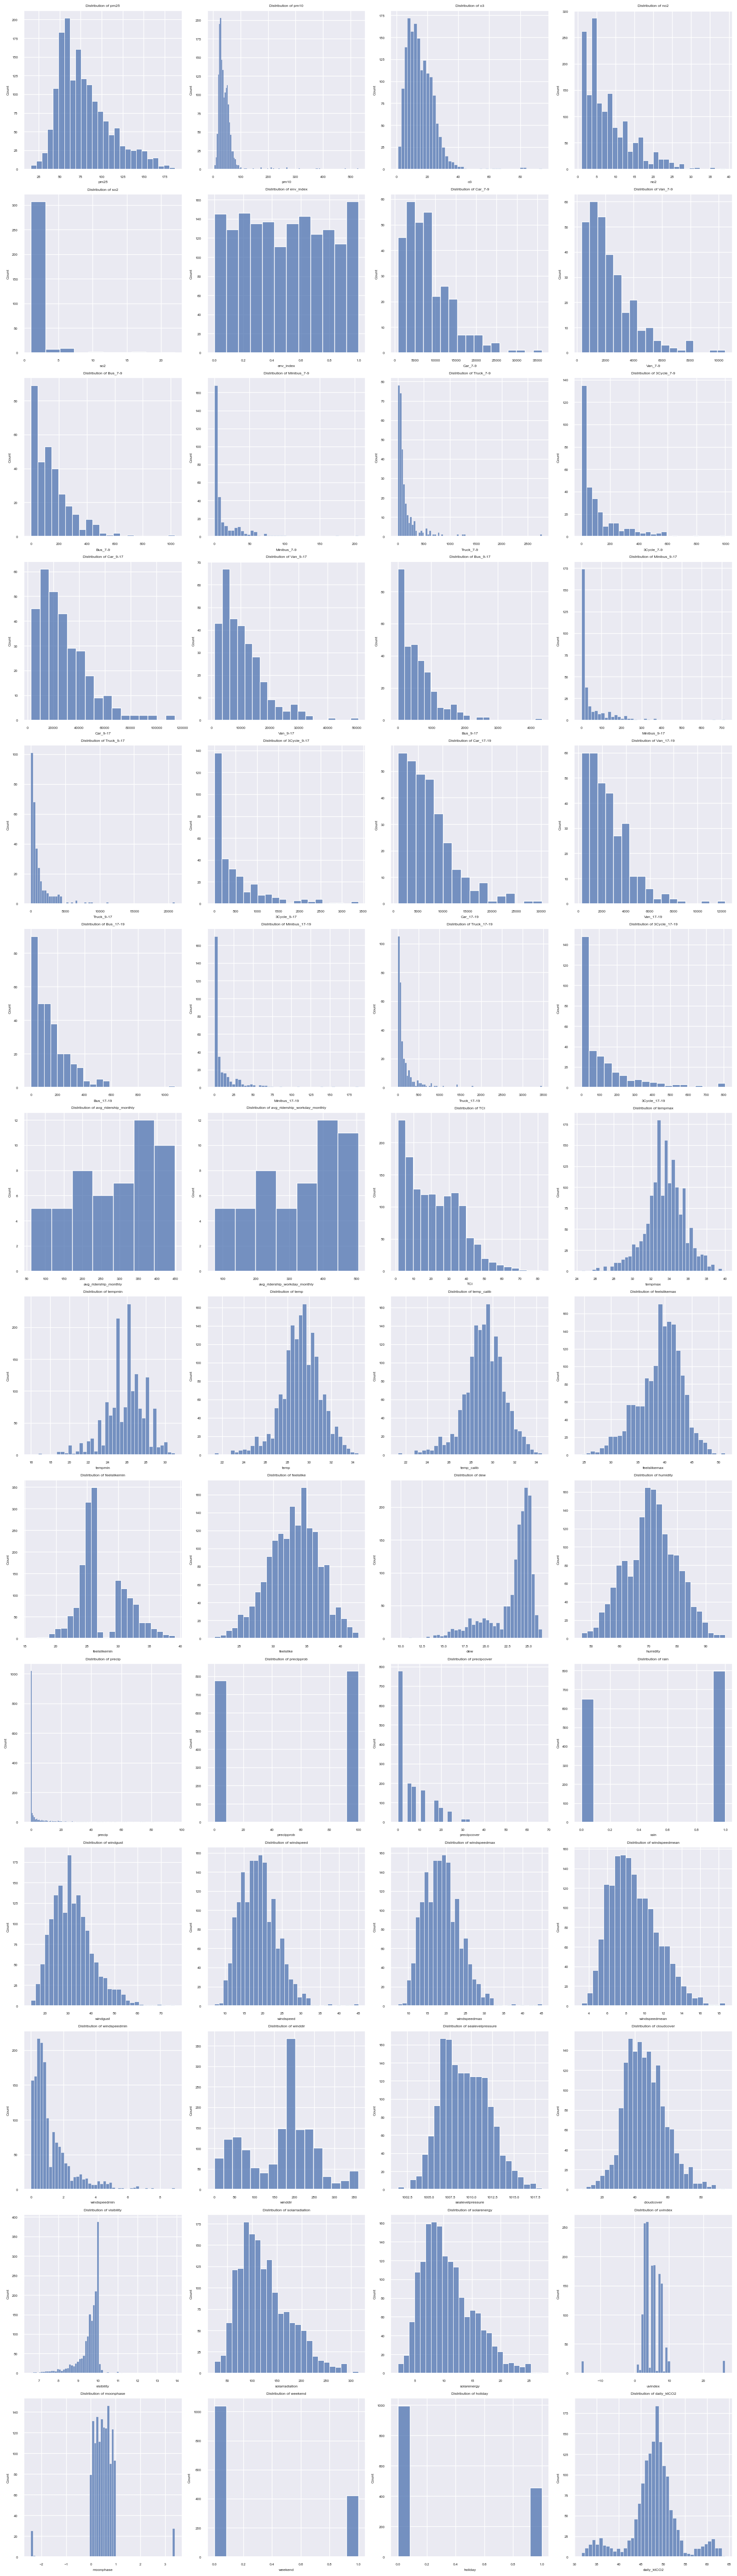

In [167]:
numerical_cols = [col for col in train_df.columns if train_df[col].dtype in [np.int64, np.float64]]
categorical_cols = [col for col in train_df.columns if train_df[col].dtype == 'object']

fig, axes = plt.subplots(len(numerical_cols) // 4, 4, figsize=(16, 4 * (len(numerical_cols) // 4)))
for ax, col in zip(axes.flatten(), numerical_cols):
    sns.histplot(x=col, data=train_df, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show();

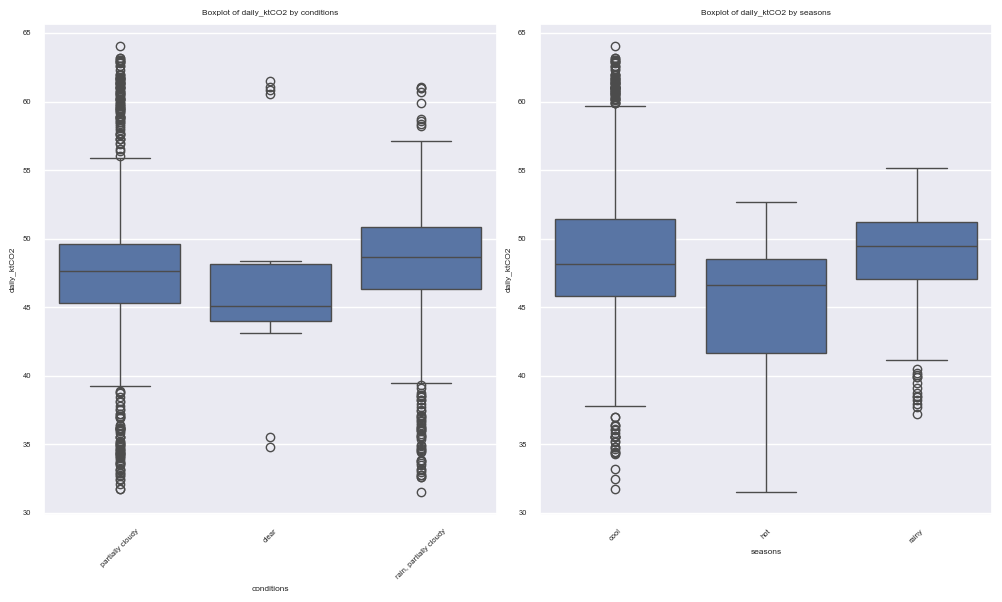

In [168]:
fig, axes = plt.subplots(len(categorical_cols)//2, 2,figsize=(10, 6))

for ax, col in zip(axes.flatten(), categorical_cols):
    sns.boxplot(x=col, y='daily_ktCO2', data=train_df, ax=ax)
    ax.set_title(f'Boxplot of daily_ktCO2 by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show();

Cooler seasons like cool and rainy tend to produce higher daily CO2 compared to hot seasons. Partially Cloudy and Rain also produce higher CO2 compared to clear condition.

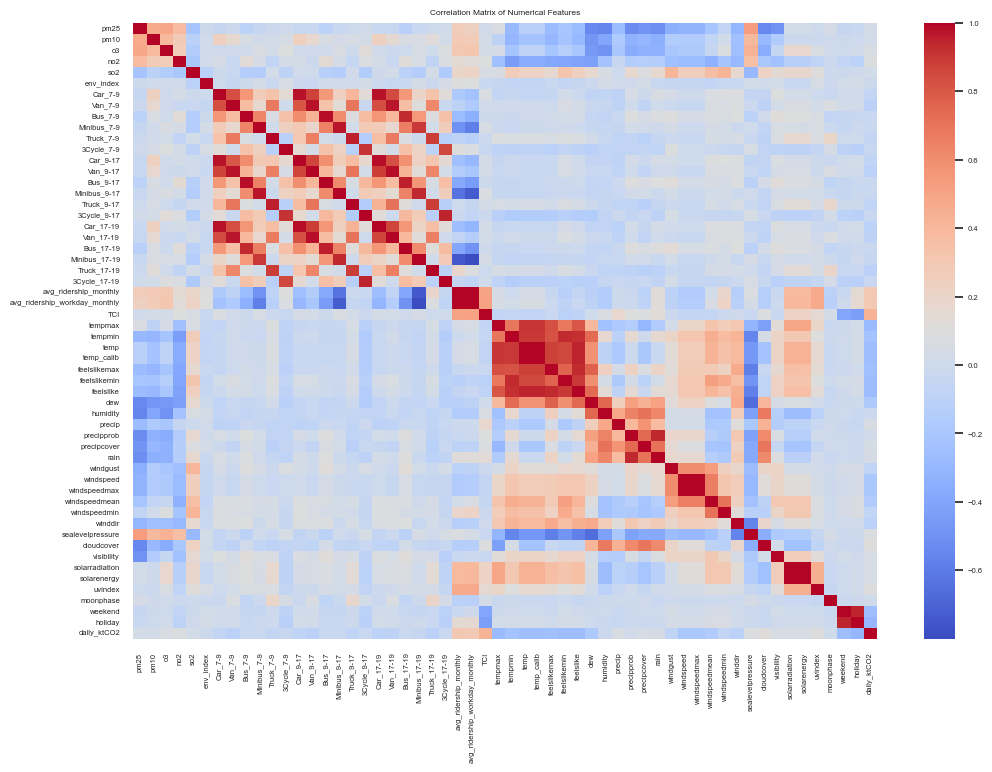

In [169]:
corr_df = train_df[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show();

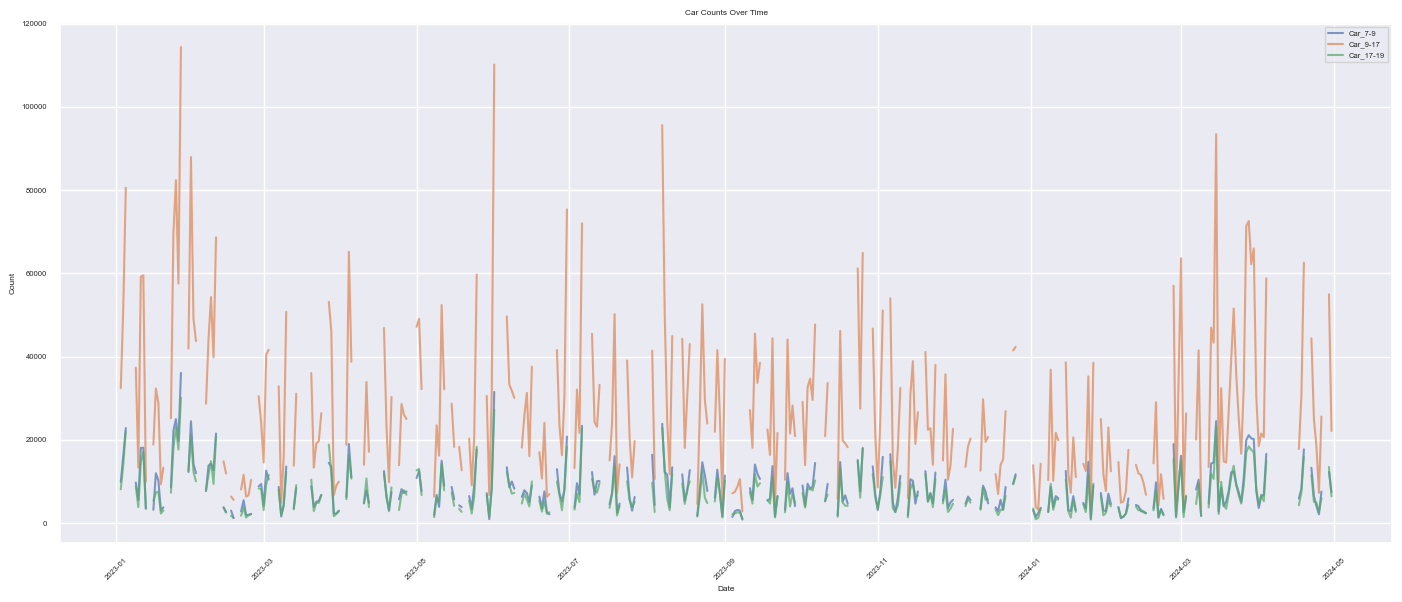

In [170]:
# See Car_7_9, Car_9_17, Car_17_19 over the days

plt.figure(figsize=(14, 6))
plt.plot(train_df['date'], train_df['Car_7-9'], label='Car_7-9', alpha=0.7)
plt.plot(train_df['date'], train_df['Car_9-17'], label='Car_9-17', alpha=0.7)
plt.plot(train_df['date'], train_df['Car_17-19'], label='Car_17-19', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Car Counts Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show();


Some missing values in car columns as well as vans, etc. The data only starts at 2023 and there are some gaps in between.

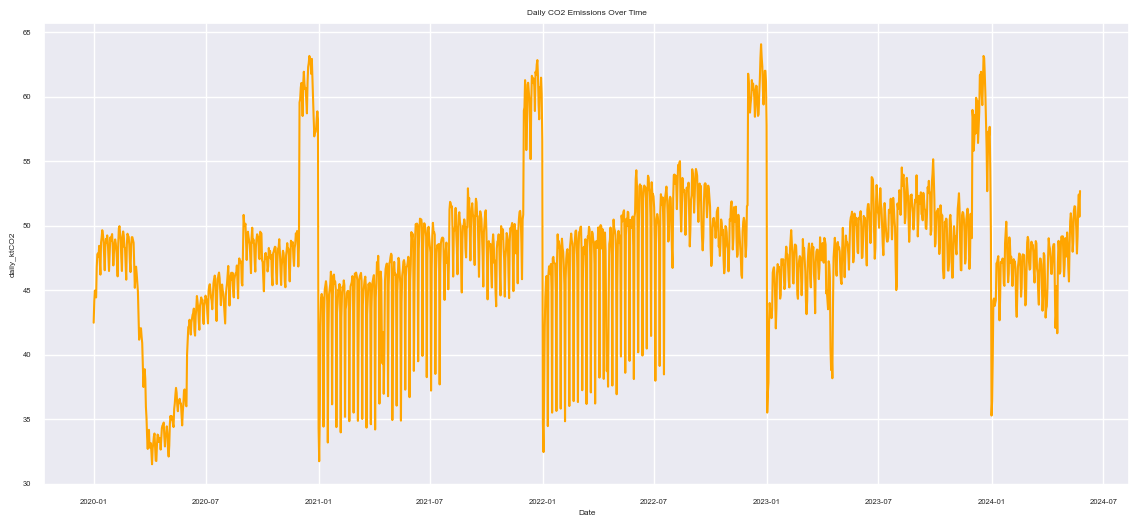

In [171]:
# Look at the trend of daily CO2 over the days

plt.figure(figsize=(14, 6))
plt.plot(train_df['date'], train_df['daily_ktCO2'], label='daily_ktCO2', color='orange')
plt.xlabel('Date')
plt.ylabel('daily_ktCO2')
plt.title('Daily CO2 Emissions Over Time')
plt.show();

We have a seasonal pattern in daily CO2 emmission.

In [172]:
yearly_stats = train_df.groupby(train_df['date'].dt.year)['daily_ktCO2'].agg(['mean', 'std'])
print(yearly_stats)

           mean       std
date                     
2020  45.360776  6.828492
2021  47.471584  5.518292
2022  49.696331  5.360615
2023  49.547975  4.018520
2024  46.933250  2.568029


CO2 increases from 2020 to 2022 and then decreases from 2022 to 2024.

# 3. Feature Engineering

In [173]:
def add_time_features(df):
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_year'] = df['date'].dt.dayofyear
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['year'] = df['date'].dt.year
    df['quarter'] = df['date'].dt.quarter
    df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
    return df

In [174]:
def add_cyclical_features(df, col, period):
    """Add sine/cosine encoding for cyclical features"""
    if col in df.columns:
        df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
        df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period)
        df.drop(columns=[col], inplace=True)
    return df

In [175]:
def add_feature_interactions(df, cols, type):
    col_1 = cols[0]
    col_2 = cols[1]
    if type == 'multiply':
        df[f'{col_1}_x_{col_2}'] = df[col_1] * df[col_2]
    elif type == 'divide':
        df[f'{col_1}_div_{col_2}'] = df[col_1] / (df[col_2] + 1e-6)  # avoid division by zero
    return df

In [176]:
def add_lag_features(df, col, lags):
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    return df

In [177]:
def handle_missing_data(df):
    missing_analysis = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df)) * 100
    })
    missing_analysis = missing_analysis[missing_analysis['missing_count'] > 0].sort_values('missing_pct', ascending=False)

    print("Columns with missing values:")
    print(missing_analysis.to_string(index=False))

    # buang sng missing lebih dari 70 karena ya bad aja kurang berguna datae takut bias
    high_missing_cols = missing_analysis[missing_analysis['missing_pct'] > 70]['column'].tolist()
    if high_missing_cols:
        df = df.drop(columns=high_missing_cols)
        print(f"\nDropped {len(high_missing_cols)} columns with >70% missing data:")
        print(high_missing_cols)
    
    return df


In [178]:
def impute_missing_data(df):
    numerical_cols = [col for col in df.columns if df[col].dtype in [np.int64, np.float64]]
    categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
    # Numerical imputation
    for col in numerical_cols:
        if df[col].isnull().any():
            skewness = df[col].skew()
            if abs(skewness) > 2:  # Highly skewed pake median -> tujuan biar puncak e ga geser jauh
                fill_val = df[col].median()
            else: # kalau udah terdistribusi baik ya tinggal diisi mean aja
                fill_val = df[col].mean()
            df[col] = df[col].fillna(fill_val)

    # Categorical imputation
    for col in categorical_cols:
        if df[col].isnull().any():
            mode_vals = df[col].mode()
            fill_val = mode_vals[0] if len(mode_vals) > 0 else 'unknown'
            df[col] = df[col].fillna(fill_val)
    return df

In [179]:
def one_hot_encode(df):
    categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print("One Hot Encoding done.")
    return df

In [ ]:
def handle_outliers(df):
    #numerical_cols = [col for col in df.columns if df[col].dtype in [np.int64, np.float64]]
    numerical_cols = ['moonphase']
    # handle outlier pake IQR method alesan e biar ga terlalu skewed aja in case ada sng skewed parah
    outlier_count = 0
    for col in numerical_cols:
        Q1, Q3 = combined_df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        if outliers_before > 0:
            print("Detected outliers in column '{}': {}".format(col, outliers_before))
            df[col] = np.clip(df[col], lower_bound, upper_bound)
            outlier_count += outliers_before

    print(f"Handled {outlier_count} outliers across all features")
    return df

In [191]:
combined_df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2008 entries, 0 to 2007
Data columns (total 51 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              2008 non-null   datetime64[ns]
 1   pm25                              2008 non-null   float64       
 2   pm10                              2008 non-null   float64       
 3   o3                                2008 non-null   float64       
 4   no2                               2008 non-null   float64       
 5   so2                               2008 non-null   float64       
 6   env_index                         2008 non-null   float64       
 7   TCI                               2008 non-null   float64       
 8   tempmax                           2008 non-null   float64       
 9   tempmin                           2008 non-null   float64       
 10  temp                              2008 non-null 

In [183]:
combined_df_c = handle_missing_data(combined_df)
combined_df_c = impute_missing_data(combined_df_c)
combined_df_c = handle_outliers(combined_df_c)
combined_df_c = one_hot_encode(combined_df_c)
combined_df_c = add_time_features(combined_df_c)
combined_df_c = add_cyclical_features(combined_df_c, 'winddir', 360)
combined_df_c = add_feature_interactions(combined_df_c, ['temp', 'humidity'], 'multiply')
combined_df_c = add_feature_interactions(combined_df_c, ['pm25', 'pm10'], 'divide')

Columns with missing values:
                       column  missing_count  missing_pct
avg_ridership_workday_monthly           1942    96.713147
        avg_ridership_monthly           1942    96.713147
                  3Cycle_9-17           1471    73.256972
                     Van_9-17           1471    73.256972
                 3Cycle_17-19           1471    73.256972
                  Truck_17-19           1471    73.256972
                Minibus_17-19           1471    73.256972
                    Bus_17-19           1471    73.256972
                    Van_17-19           1471    73.256972
                    Car_17-19           1471    73.256972
                   Truck_9-17           1471    73.256972
                 Minibus_9-17           1471    73.256972
                     Bus_9-17           1471    73.256972
                     Car_9-17           1471    73.256972
                   3Cycle_7-9           1471    73.256972
                    Truck_7-9           147

In [189]:
# ngerapiin nama header/column
combined_df_c.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in combined_df_c.columns]
combined_df_c.columns = [re.sub(r'_+', '_', col).strip('_') for col in combined_df_c.columns]

# 4. Model Building

In [ ]:
train_len = len(train_y)
X_train = combined_df_c.iloc[:train_len].copy()
X_test = combined_df_c.iloc[train_len:].copy()

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

In [184]:
def get_models_for_cv():
    """Returns models for cross_val_score (no early stopping)"""
    return {
        'lightgbm': lgb.LGBMRegressor(random_state=42, n_estimators=1000, learning_rate=0.05, verbose=-1),
        'xgboost': xgb.XGBRegressor(random_state=42, n_estimators=1000, learning_rate=0.05, verbosity=0),
        'catboost': cb.CatBoostRegressor(random_state=42, iterations=1000, learning_rate=0.05, verbose=0),
        'random_forest': RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1),
        'extra_trees': ExtraTreesRegressor(random_state=42, n_estimators=200, n_jobs=-1),
        'gradient_boosting': GradientBoostingRegressor(random_state=42, n_estimators=200, learning_rate=0.1),
        'ridge': RidgeCV(alphas=np.logspace(-4, 4, 20)),
        'elastic_net': ElasticNetCV(alphas=np.logspace(-4, 4, 10), l1_ratio=[0.1, 0.5, 0.9], cv=5),
        'lasso': LassoCV(alphas=np.logspace(-4, 4, 20), cv=5)
    }

In [190]:
print("\nStep 6: Building and Training Models using Out-of-Fold Stacking...")
train_len = len(train_y)
X_train = combined_df_c.iloc[:train_len].copy()
X_train.drop(columns=['date'], inplace=True)
X_test = combined_df_c.iloc[train_len:].copy()
X_test.drop(columns=['date'], inplace=True)

# Cross-validation setup
NFOLDS = 5
tsfold = TimeSeriesSplit(n_splits=NFOLDS)

def objective_lgb(trial):
    params = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.1),
        'num_leaves': trial.suggest_int("num_leaves", 2, 256),
        'max_depth': trial.suggest_int("max_depth", -1, 50),
        'min_child_samples': trial.suggest_int("min_child_samples", 5, 100),
        'subsample': trial.suggest_float("subsample", 0.5, 1.0),
        'colsample_bytree': trial.suggest_float("colsample_bytree", 0.5, 1.0),
        'bagging_freq': trial.suggest_int("bagging_freq", 1, 10),
        'bagging_fraction': trial.suggest_float("bagging_fraction", 0.5, 1.0),
        'feature_fraction': trial.suggest_float("feature_fraction", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbose': -1
    }
    model = lgb.LGBMRegressor(**params)
    cv_scores = cross_val_score(model, X_train, train_y, cv=tsfold,
                                scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -cv_scores.mean()


def objective_xgb(trial):
    params = {
        'n_estimators': 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbosity': 0
    }
    model = xgb.XGBRegressor(**params)
    cv_scores = cross_val_score(model, X_train, train_y, cv=tsfold,
                                scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -cv_scores.mean()


def objective_cat(trial):
    params = {
        'iterations': 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-5, 10.0, log=True),
        'verbose': 0,
        'random_state': 42
    }
    model = cb.CatBoostRegressor(**params)
    cv_scores = cross_val_score(model, X_train, train_y, cv=tsfold,
                                scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -cv_scores.mean()


def objective_random_forest(trial):
    params = {
        'n_estimators': trial.suggest_int("n_estimators", 100, 500),
        'max_depth': trial.suggest_int("max_depth", 5, 30),
        'min_samples_split': trial.suggest_int("min_samples_split", 2, 20),
        'min_samples_leaf': trial.suggest_int("min_samples_leaf", 1, 20),
        'max_features': trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        'random_state': 42,
        'n_jobs': -1
    }
    model = RandomForestRegressor(**params)
    cv_scores = cross_val_score(model, X_train, train_y, cv=tsfold,
                                scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -cv_scores.mean()


def objective_extra_trees(trial):
    params = {
        'n_estimators': trial.suggest_int("n_estimators", 100, 500),
        'max_depth': trial.suggest_int("max_depth", 5, 30),
        'min_samples_split': trial.suggest_int("min_samples_split", 2, 20),
        'min_samples_leaf': trial.suggest_int("min_samples_leaf", 1, 20),
        'max_features': trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        'random_state': 42,
        'n_jobs': -1
    }
    model = ExtraTreesRegressor(**params)
    cv_scores = cross_val_score(model, X_train, train_y, cv=tsfold,
                                scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -cv_scores.mean()


def objective_gradient_boosting(trial):
    params = {
        'n_estimators': trial.suggest_int("n_estimators", 100, 500),
        'learning_rate': trial.suggest_float("learning_rate", 0.01, 0.2),
        'max_depth': trial.suggest_int("max_depth", 3, 10),
        'random_state': 42
    }
    model = GradientBoostingRegressor(**params)
    cv_scores = cross_val_score(model, X_train, train_y, cv=tsfold,
                                scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -cv_scores.mean()

    

study_lgb = optuna.create_study(direction="minimize")
study_lgb.optimize(lambda trial: objective_lgb(trial), n_trials=25, show_progress_bar=True)

study_xgb = optuna.create_study(direction="minimize")
study_xgb.optimize(lambda trial: objective_xgb(trial), n_trials=25, show_progress_bar=True)

study_cat = optuna.create_study(direction="minimize")
study_cat.optimize(lambda trial: objective_cat(trial), n_trials=25, show_progress_bar=True)

study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(lambda trial: objective_random_forest(trial), n_trials=25, show_progress_bar=True)

study_et = optuna.create_study(direction="minimize")
study_et.optimize(lambda trial: objective_extra_trees(trial), n_trials=25, show_progress_bar=True)

study_gb = optuna.create_study(direction="minimize")
study_gb.optimize(lambda trial: objective_gradient_boosting(trial), n_trials=25, show_progress_bar=True)

best_params = {
    "lightgbm": study_lgb.best_trial.params,
    "xgboost": study_xgb.best_trial.params,
    "catboost": study_cat.best_trial.params,
    "random_forest": study_rf.best_trial.params,
    "extra_trees": study_et.best_trial.params,
    'gradient_boosting': study_gb.best_trial.params
}

def get_models():
    """Return dictionary of models with optimized hyperparameters"""
    return {
        'lightgbm': lgb.LGBMRegressor(
            **best_params['lightgbm'],
            random_state=42, n_estimators=1000, verbose=-1
        ),
        'xgboost': xgb.XGBRegressor(
            **best_params['xgboost'],
            random_state=42, n_estimators=1000, verbosity=0
        ),
        'catboost': cb.CatBoostRegressor(
            **best_params['catboost'],
            random_state=42, iterations=1000, verbose=0
        ),
        'random_forest': RandomForestRegressor(
            **best_params['random_forest'],
            random_state=42, n_jobs=-1
        ),
        'extra_trees': ExtraTreesRegressor(
            **best_params['extra_trees'],
            random_state=42, n_jobs=-1
        ),
        'gradient_boosting': GradientBoostingRegressor(
            **best_params['gradient_boosting'],
            random_state=42
        ),
        
        # Linear models 
        'ridge': RidgeCV(alphas=np.logspace(-4, 4, 20)),
        'elastic_net': ElasticNetCV(alphas=np.logspace(-4, 4, 10), 
                                   l1_ratio=[0.1, 0.5, 0.7, 0.9], cv=5),
        'lasso': LassoCV(alphas=np.logspace(-4, 4, 20), cv=5)
    }

# Single model evaluation
print("\n" + "="*60)
print("INDIVIDUAL MODEL PERFORMANCE")
print("="*60)

models = get_models()
model_scores = {}
model_predictions = {}

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    cv_scores = cross_val_score(model, X_train, train_y, cv=tsfold, 
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_rmse = -cv_scores.mean()
    cv_std = cv_scores.std()
    
    model_scores[name] = {'cv_rmse': cv_rmse, 'cv_std': cv_std}
    
    model.fit(X_train, train_y)
    test_pred = model.predict(X_test)
    model_predictions[name] = test_pred
    
    print(f"  CV RMSE: {cv_rmse:.4f} (±{cv_std:.4f})")

print(f"\n{'Model':<15} {'CV RMSE':<10} {'Std':<10}")
print("-" * 35)
for name, scores in sorted(model_scores.items(), key=lambda x: x[1]['cv_rmse']):
    print(f"{name:<15} {scores['cv_rmse']:<10.4f} {scores['cv_std']:<10.4f}")

[I 2025-09-14 18:58:21,449] A new study created in memory with name: no-name-43defd16-c0b8-4cf4-aac6-7e2676edf0f7



Step 6: Building and Training Models using Out-of-Fold Stacking...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-09-14 18:58:57,854] Trial 0 finished with value: 3.9602416230862723 and parameters: {'learning_rate': 0.07786259068856047, 'num_leaves': 32, 'max_depth': 26, 'min_child_samples': 49, 'subsample': 0.8157867403634966, 'colsample_bytree': 0.5036547579251853, 'bagging_freq': 6, 'bagging_fraction': 0.8655060152537124, 'feature_fraction': 0.8519873078465504, 'reg_lambda': 1.047845817375112e-08, 'reg_alpha': 0.0008183096464200125}. Best is trial 0 with value: 3.9602416230862723.
[I 2025-09-14 18:59:24,971] Trial 1 finished with value: 3.7765297597356393 and parameters: {'learning_rate': 0.026429385575664203, 'num_leaves': 176, 'max_depth': 31, 'min_child_samples': 29, 'subsample': 0.8909817269741778, 'colsample_bytree': 0.6178013179045243, 'bagging_freq': 5, 'bagging_fraction': 0.6969165169075732, 'feature_fraction': 0.7802427039016391, 'reg_lambda': 0.0011280852203712447, 'reg_alpha': 5.570908768264046e-07}. Best is trial 1 with value: 3.7765297597356393.
[I 2025-09-14 19:01:10,986] 

KeyboardInterrupt: 

In [192]:
import pmdarima as pmd

model=pmd.auto_arima(train_y,start_p=1,start_q=1,test='adf',m=12,seasonal=True,trace=True)
model

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[12] intercept   : AIC=inf, Time=53.98 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=10087.422, Time=5.12 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=8201.724, Time=27.15 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=8717.329, Time=6.37 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=17010.215, Time=0.64 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=8207.501, Time=6.87 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=8199.727, Time=113.67 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=30.89 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=9.86 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=9607.037, Time=21.48 sec
 ARIMA(2,0,0)(2,0,0)[12] intercept   : AIC=8107.272, Time=31.31 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=8156.422, Time=10.00 sec
 ARIMA(2,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=26.61 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=17.07 sec
 ARIMA(3,0,0)(2,0,0)[12] interce

,order,"(5, ...)"
,seasonal_order,"(1, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,True
